# Inspection of Feature Engineering Results
This notebook verifies the output of the feature engineering scripts in `src/features`. We load the generated Parquet files and visualize key attributes to ensure the data is correct.

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import os

FEATURE_DIR = "../data/processed/features"
ROADS_PATH = "../data/processed/road_segments.gpkg"

def load_feature(name):
    path = os.path.join(FEATURE_DIR, f"{name}.parquet")
    if os.path.exists(path):
        return pd.read_parquet(path)
    return None

## 1. Load Generated Features
We check which feature files have been successfully generated.

In [2]:
df_road = load_feature("feat_road")
df_acc = load_feature("feat_accidents")
df_spatial = load_feature("feat_spatial")

if df_road is not None: print(f"Road Features: {df_road.shape}")
if df_acc is not None: print(f"Accident Features: {df_acc.shape}")
if df_spatial is not None: print(f"Spatial Features: {df_spatial.shape}")

Road Features: (276062, 5)
Accident Features: (276062, 12)
Spatial Features: (276062, 8)


## 2. Merging for Inspection
We join the features to the road segments map for visualization.

In [3]:
gdf_roads = gpd.read_file(ROADS_PATH)

# Merge road attributes
if df_road is not None:
    gdf_roads = gdf_roads.merge(df_road, on="segment_id", how="left")

# Merge accident counts
if df_acc is not None:
    gdf_roads = gdf_roads.merge(df_acc, on="segment_id", how="left")
    gdf_roads['acc_total'] = gdf_roads['acc_total'].fillna(0)

# Merge spatial context
if df_spatial is not None:
    gdf_roads = gdf_roads.merge(df_spatial, on="segment_id", how="left")

gdf_roads.head()

,segment_id,osm_id,highway_x,name,oneway,lanes_x,length_m_x,geometry,highway_y,highway_rank,...,acc_late_night,acc_monsoon,acc_dry,dist_intersection_m,poi_count_200m,dist_school_m,dist_hospital_m,dist_fuel_m,dist_mall_m,building_density_200m
0,0,416364403,unclassified,ถนนลัดคลองตัน,nan,2,100.0,"LINESTRING (651714.208 1493571.685, 651727.008...",unclassified,1,...,0,0,0,6598.5,0,3011.4,3209.4,2652.8,15772.0,0
1,1,416364403,unclassified,ถนนลัดคลองตัน,nan,2,100.0,"LINESTRING (651755.629 1493498.386, 651790.335...",unclassified,1,...,0,0,0,6586.4,0,2975.8,3169.6,2615.5,15772.7,0
2,2,416364403,unclassified,ถนนลัดคลองตัน,nan,2,100.0,"LINESTRING (651849.872 1493531.814, 651894.915...",unclassified,1,...,0,0,0,6528.7,0,2895.0,3085.0,2533.3,15729.0,0
3,3,416364403,unclassified,ถนนลัดคลองตัน,nan,2,100.0,"LINESTRING (651943.102 1493567.916, 651946.321...",unclassified,1,...,0,0,0,6469.0,1,2813.3,2999.5,2450.5,15682.5,5
4,4,416364403,unclassified,ถนนลัดคลองตัน,nan,2,100.0,"LINESTRING (652027.804 1493617.818, 652028.665...",unclassified,1,...,0,0,0,6385.6,1,2717.4,2901.9,2354.0,15608.2,9


## 3. Visualize Feature Distribution
Let's look at the distribution of accidents and distances to points of interest (POI).

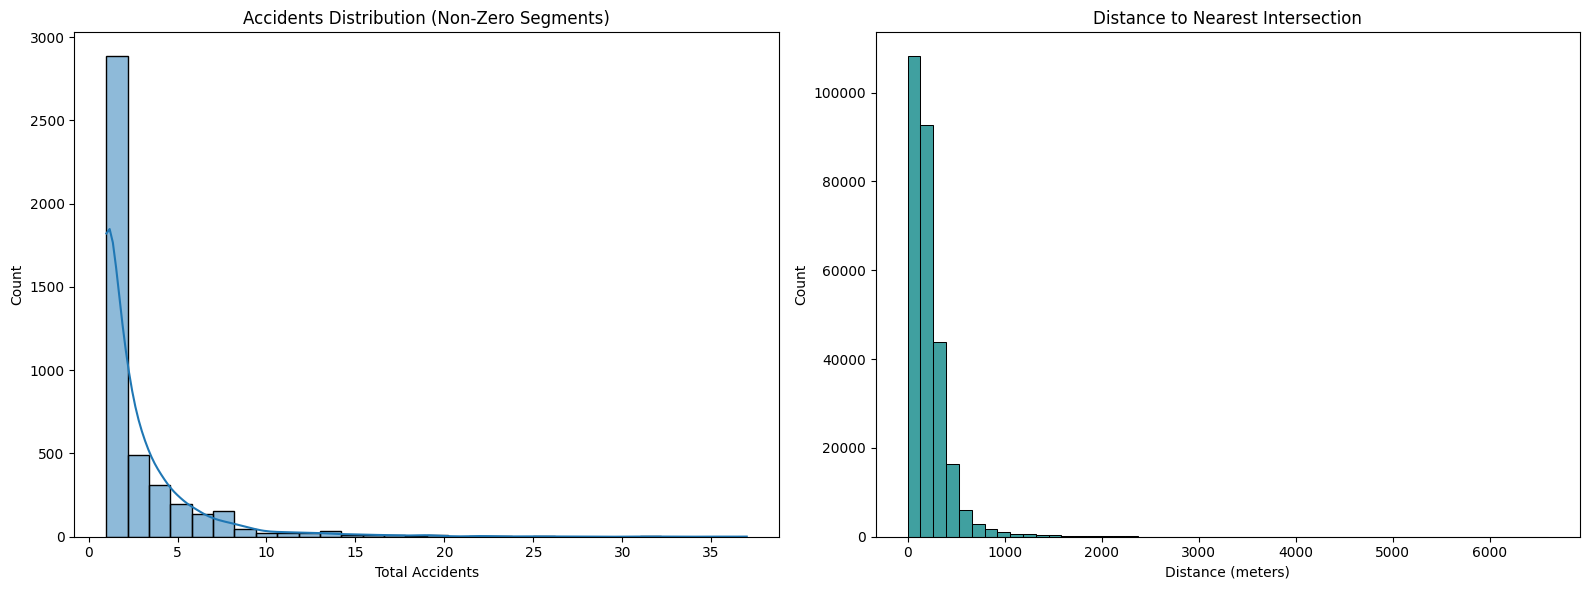

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Total Accidents per segment
sns.histplot(gdf_roads[gdf_roads['acc_total'] > 0]['acc_total'], bins=30, ax=axes[0], kde=True)
axes[0].set_title('Accidents Distribution (Non-Zero Segments)')
axes[0].set_xlabel('Total Accidents')

# Distance to Intersection
if 'dist_intersection_m' in gdf_roads.columns:
    sns.histplot(gdf_roads['dist_intersection_m'], bins=50, ax=axes[1], color='teal')
    axes[1].set_title('Distance to Nearest Intersection')
    axes[1].set_xlabel('Distance (meters)')

plt.tight_layout()
plt.show()

## 4. Map Visualization
We visualize the accident risk (total accidents) on a small section of the city.

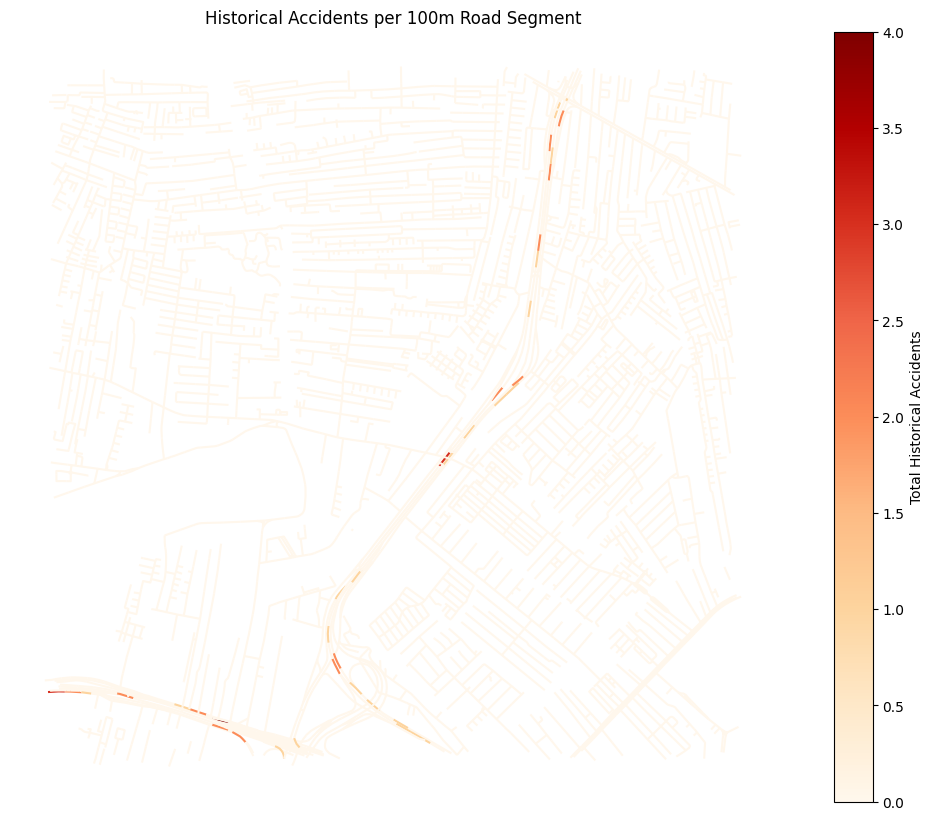

In [5]:
# Filter to a busy area for clear visualization
center_x, center_y = gdf_roads.geometry.centroid.x.median(), gdf_roads.geometry.centroid.y.median()
zoom_radius = 2000 # 2km
subset = gdf_roads.cx[center_x-zoom_radius : center_x+zoom_radius, center_y-zoom_radius : center_y+zoom_radius]

fig, ax = plt.subplots(figsize=(15, 10))
subset.plot(ax=ax, column='acc_total', cmap='OrRd', linewidth=1.5, legend=True, 
            legend_kwds={'label': "Total Historical Accidents"})
ax.set_title('Historical Accidents per 100m Road Segment')
ax.set_axis_off()
plt.show()